### Imports and Setup

In [1]:
import os

from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import yaml
import numpy as np
import torch
from PIL import Image

from models.fusion_tcn import FusionTCN
from datasets.dataloaders import get_dataloaders
from utils.transformations import get_image_transform
from utils.transformations import to_spect

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print("Using the GPU!")
else:
    print("WARNING: Could not find GPU. Using CPU only.")
    
# load config file
with open("config.yaml", 'r') as yaml_file:
    config = yaml.load(yaml_file, Loader=yaml.Loader)

Using the GPU!


Settings for evaluation

In [2]:
split = 'test'

### Prepare For Evaluation
Get dataloaders

In [3]:
dl = get_dataloaders(splits=['train', 'val', 'test'],
                    batch_size=64,
                    shuffle=False,
                    transform=get_image_transform(),
                    squeeze=True,
                    num_workers=20)

Load the desired model

In [4]:
model = FusionTCN(num_inputs=dl[split].dataset.num_TOSSITs,
                num_outputs=2,
                input_size=dl[split].dataset.size[0], 
                output_size=2,
                num_channels=[250] + [500] + [368]*(8-2),
                kernel_size=6,
                dropout=0.05).to(device)

# load model weights
state_dict = torch.load(os.path.join(config['models']['checkpoints_directories'] + '/large_chan', 'weights_50.pt'),
                        map_location=device)['model_state_dict']
model.load_state_dict(state_dict)

<All keys matched successfully>

### Evaluate Model On Synthetic Data
Get predictions and labels

In [5]:
def evaluate_model(model, dataloader):
    """
    Get lists of targets and predictions using a provided model and dataloader.
    
    Parameters
    ----------
    model : nn.Module
        model to be evaluated
    dataloader : data.DataLoader
        dataloader to use in model evaluation
    
    Returns
    -------
    x_p : array-like
        list of predicted X components
    x_t : array-like
        list of true X components
    y_p : array-like
        list of predicted Y components
    y_t : array-like
        list of true Y components
    outputs_all : array-like
        all model outputs
    """
    # put model in evaluatio mode
    model.eval()
    
    # get target scaling values
    max_x = dataloader.dataset.max_x
    max_y = dataloader.dataset.max_y
    
    # initialize arrays for results
    x_t, x_p, y_t, y_p, outputs_all = [], [], [], [], []
    
    for inputs, x_targets, y_targets in tqdm(dataloader):
        
        # put data on device
        inputs = inputs.to(device)
        x_targets = x_targets.to(device)
        y_targets = y_targets.to(device)
        
        with torch.set_grad_enabled(False):
            # get outputs and store
            outputs = model(inputs)
            
            outputs_all += outputs.detach().tolist()
            
            # store x predictions and labels
            x_p += (outputs[:,[0]] * max_x).detach().tolist()
            x_t += (x_targets * max_x).detach().tolist()
            
            # store y predictions and labels
            y_p += (outputs[:,[1]] * max_y).detach().tolist()
            y_t += (y_targets * max_y).detach().tolist()
    
    return np.asarray(x_p), np.asarray(x_t), np.asarray(y_p), np.asarray(y_t), np.asarray(outputs_all)

In [6]:
x_p, x_t, y_p, y_t, outputs_all = evaluate_model(model, dl[split])

  0%|          | 0/23 [00:00<?, ?it/s]

Plot predicteda and true X/Y componenets and rought predicted and true range

In [7]:
def plot_regressions(x_t, x_p, y_t, y_p):
    """
    Plot regression results.
    
    Parameters
    ----------
    x_p : array-like
        list of predicted X components
    x_t : array-like
        list of true X components
    y_p : array-like
        list of predicted Y components
    y_t : array-like
        list of true Y components
    """
    
    # convert to km
    x_t = x_t / 1000
    x_p = x_p / 1000
    y_t = y_t / 1000
    y_p = y_p / 1000
    
    # rough range error (assuming flat Earth)
    r_t = np.sqrt(x_t ** 2 + y_t ** 2)
    r_p = np.sqrt(x_p ** 2 + y_t ** 2)
    
    # get endpoints for identity lines
    x_mm = (np.min(x_t), np.max(x_t))
    y_mm = (np.min(y_t), np.max(y_t))
    r_mm = (np.min(r_t), np.max(r_t))
    
    f, (ax1, ax2, ax3) = plt.subplots(1, 3)
    f.set_figheight(4)
    f.set_figwidth(15)
    
    # X component
    ax1.plot(x_t, x_p, 'bo', markersize=2, label="predictions")
    ax1.plot([x_mm[0], x_mm[1]], [x_mm[0], x_mm[1]], 'r--', label="identity line")
    ax1.legend()
    ax1.grid()
    ax1.set_xlabel("True X Component [km]")
    ax1.set_ylabel("Predicted Distance [km]")
    
    # Y component
    ax2.plot(y_t, y_p, 'bo', markersize=2, label="predictions")
    ax2.plot([y_mm[0], y_mm[1]], [y_mm[0], y_mm[1]], 'r--', label="identity line")
    ax2.legend()
    ax2.grid()
    ax2.set_xlabel("True Y Component [km]")
    
    # rough range
    ax3.plot(r_t, r_p, 'bo', markersize=2, label="predictions")
    ax3.plot([r_mm[0], r_mm[1]], [r_mm[0], r_mm[1]], 'r--', label="identity line")
    ax3.legend()
    ax3.grid()
    ax3.set_xlabel("True Rough Range [km]")
    
    # calculate component errors
    MSE_X = ((x_t - x_p) ** 2).mean()
    MSE_Y = ((y_t - y_p) ** 2).mean()
    MSE_R = ((r_t - r_p) ** 2).mean()
    
    print("statistics")
    print("-------------------")
    print("MSE (X): {:.3f} km^2".format(MSE_X))
    print("RMSE (X): {:.3f} km".format(np.sqrt(MSE_X)))
    print("-------------------")
    print("MSE (Y): {:.3f} km^2".format(MSE_Y))
    print("RMSE (Y): {:.3f} km".format(np.sqrt(MSE_Y)))
    print("-------------------")
    print("MSE (R): {:.3f} km^2".format(MSE_R))
    print("RMSE (R): {:.3f} km".format(np.sqrt(MSE_R)))
    print("-------------------")

statistics
-------------------
MSE (X): 0.408 km^2
RMSE (X): 0.639 km
-------------------
MSE (Y): 0.452 km^2
RMSE (Y): 0.672 km
-------------------
MSE (R): 0.194 km^2
RMSE (R): 0.441 km
-------------------


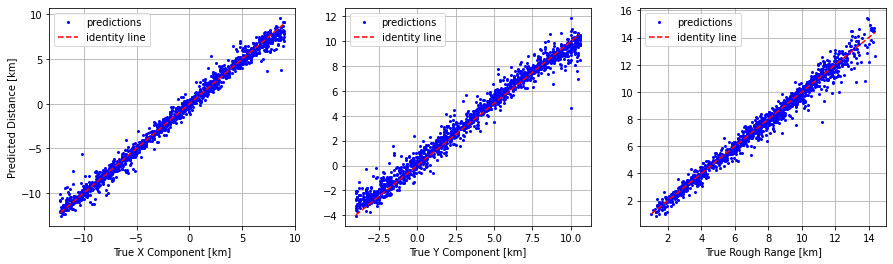

In [8]:
plot_regressions(x_t, x_p, y_t, y_p)

### Display High Error Calls

In [9]:
def plot_top_k_error(x_t, x_p, y_t, y_p, dataloader, k=5, highest=True):
    
    # get data, labels, and indices of split
    dataset = dataloader.dataset.inputs['data']
    labels = dataloader.dataset.inputs['labels']
    idx = dataloader.batch_sampler.idx
    
    # sum X/Y absolute errors and get indices from largest to smallest
    top_k_abs_err = (np.abs(x_t - x_p) + np.abs(y_t - y_p)) / 2
    inds = top_k_abs_err.squeeze().argsort()[::-1][:k] if highest else top_k_abs_err.squeeze().argsort()[:k]
    
    # get number of sensors per call
    num_TOSSITs = dataset.shape[1]
    
    x_list, y_list = [], []
    for d in range(k):
        # store coordinates
        top_k_X = dataset[idx[inds[d]],...]
        x_list.append(labels[idx[inds[d]],1])
        y_list.append(labels[idx[inds[d]],0])
        
        # only print details and plot signals if fewer than 32 calls
        if k <= 32:
            print("Avg. Component Error: ", np.around(top_k_abs_err[inds[d]][0], 2), " m")
            print("Y Component (GT): ", np.around(labels[idx[inds[d]],0], 2), " m")
            print("X Component (GT): ", np.around(labels[idx[inds[d]],1], 2), " m")
            print("Y Component (P): ", np.around(y_p[inds[d]].squeeze(), 2), " m")
            print("X Component (P): ", np.around(x_p[inds[d]].squeeze(), 2), " m")
            print()
            plt.figure()
            for t in range(num_TOSSITs):
                spect = to_spect(top_k_X[t])
                plt.subplot(1,num_TOSSITs, t+1)
                plt.imshow(spect.squeeze())
                plt.title(f"TOSSIT {t+1}")
                plt.axis('off')
            plt.tight_layout()
            
    # overlay points onto map
    plt.figure()
    img = Image.open(config['dataset']['data_directory'] + '/map.tif', mode='r', formats=None)
    plt.scatter(x_list, y_list, c='#0307fc', s=2)
    ylmax, ylmin = plt.gca().get_ylim()
    xlmin, xlmax = plt.gca().get_xlim()
    plt.gca().invert_yaxis()
    implot = plt.imshow(img, extent=(config['scaling']['min_x'], config['scaling']['max_x'], config['scaling']['max_y'], config['scaling']['min_y']))
    plt.xlabel("X Component [m]")
    plt.ylabel("Y Component [m]")

Avg. Component Error:  3376.47  m
Y Component (GT):  10007.51  m
X Component (GT):  8688.34  m
Y Component (P):  11856.99  m
X Component (P):  3784.87  m

Avg. Component Error:  2946.2  m
Y Component (GT):  10007.51  m
X Component (GT):  -10274.31  m
Y Component (P):  4603.1  m
X Component (P):  -10762.29  m

Avg. Component Error:  2798.0  m
Y Component (GT):  8617.58  m
X Component (GT):  7307.81  m
Y Component (P):  10577.33  m
X Component (P):  3671.56  m

Avg. Component Error:  2760.63  m
Y Component (GT):  10470.82  m
X Component (GT):  -9240.58  m
Y Component (P):  6954.95  m
X Component (P):  -11245.98  m

Avg. Component Error:  2549.16  m
Y Component (GT):  10378.16  m
X Component (GT):  -7723.37  m
Y Component (P):  7607.34  m
X Component (P):  -10050.88  m

Avg. Component Error:  2531.15  m
Y Component (GT):  -3335.84  m
X Component (GT):  8190.21  m
Y Component (P):  -297.51  m
X Component (P):  6166.24  m

Avg. Component Error:  2421.94  m
Y Component (GT):  -3799.15  m
X C

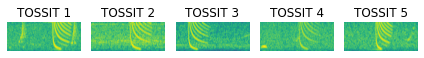

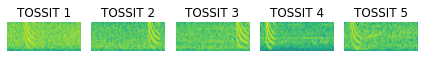

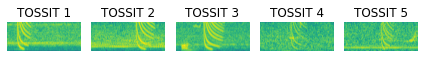

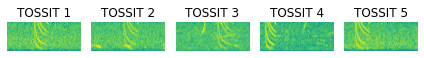

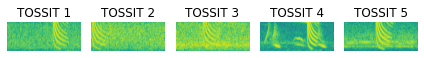

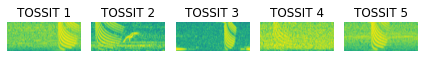

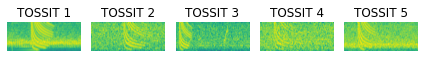

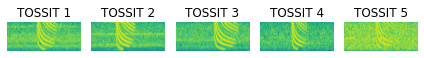

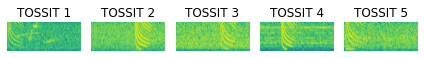

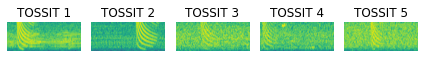

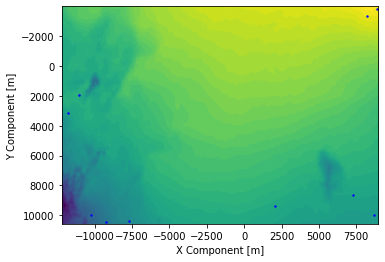

In [13]:
plot_top_k_error(x_t, 
                 x_p, 
                 y_t, 
                 y_p, 
                 dl[split],
                 highest=True,
                 k=10)